In [2]:
!pip install scikit-learn pandas numpy matplotlib seaborn tensorflow    


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\pc\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


installing main libraries that we will use 

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder # tranform from str to int
from sklearn.model_selection import train_test_split # modeling 
from sklearn.preprocessing import StandardScaler    # modeling 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input


**step 1 Dataset Collection from kaggle:**

In [4]:
os.chdir("F:\\AAST\semester 6\\Programming Applications\\archive")
print(os.listdir())
# Dataset Directory


#Pandas Data handling Library
data = pd.read_csv("F:/AAST/semester 6/Programming Applications/archive/kidney_disease_dataset.csv")

['12th Project .docx', '12th Project .ipynb', 'kidney_disease_dataset.csv', 'test.csv', 'test.xlsx', '~$test.xlsx', '~$th Project .docx']


define file locations and directory 

In [5]:
print(data.head()) 

   Id  Age  Creatinine_Level   BUN  Diabetes  Hypertension   GFR  \
0   1   71              0.30  40.9         0             1  46.8   
1   2   34              1.79  17.1         0             0  43.8   
2   3   80              2.67  15.0         0             1  78.2   
3   4   40              0.97  31.1         0             1  92.8   
4   5   43              2.05  22.8         1             1  62.2   

   Urine_Output      CKD_Status  Dialysis_Needed  
0          1622  kidney problem                0  
1          1428  kidney problem                0  
2          1015  kidney problem                0  
3          1276  kidney problem                0  
4          1154  kidney healthy                0  


print first 5 row of the data

In [6]:
print(data.info())    

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2198 entries, 0 to 2197
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Id                2198 non-null   int64  
 1   Age               2198 non-null   int64  
 2   Creatinine_Level  2198 non-null   float64
 3   BUN               2198 non-null   float64
 4   Diabetes          2198 non-null   int64  
 5   Hypertension      2198 non-null   int64  
 6   GFR               2198 non-null   float64
 7   Urine_Output      2198 non-null   int64  
 8   CKD_Status        2198 non-null   object 
 9   Dialysis_Needed   2198 non-null   int64  
dtypes: float64(3), int64(6), object(1)
memory usage: 171.8+ KB
None


to define what features are strings and to know the nulls

In [7]:
#data exploration 
print(data.describe())

                Id          Age  Creatinine_Level          BUN     Diabetes  \
count  2198.000000  2198.000000       2198.000000  2198.000000  2198.000000   
mean   1099.500000    53.954959          1.304704    18.819563     0.409008   
std     634.652267    20.470218          0.786742    10.458130     0.491763   
min       1.000000    20.000000          0.300000     5.000000     0.000000   
25%     550.250000    36.000000          0.620000    10.025000     0.000000   
50%    1099.500000    53.000000          1.240000    18.200000     0.000000   
75%    1648.750000    72.000000          1.840000    26.000000     1.000000   
max    2198.000000    90.000000          4.130000    61.900000     1.000000   

       Hypertension          GFR  Urine_Output  Dialysis_Needed  
count   2198.000000  2198.000000   2198.000000      2198.000000  
mean       0.498635    69.133030   1311.130573         0.014104  
std        0.500112    24.615674    493.821049         0.117946  
min        0.000000     

to see outliers and the average

In [8]:
print(data["CKD_Status"])

0       kidney problem
1       kidney problem
2       kidney problem
3       kidney problem
4       kidney healthy
             ...      
2193    kidney healthy
2194    kidney problem
2195    kidney problem
2196    kidney healthy
2197    kidney problem
Name: CKD_Status, Length: 2198, dtype: object


In [9]:
print(data["CKD_Status"].unique()) # to k

['kidney problem' 'kidney healthy']


to know the main statues we are dealing with 

**step 2 Dataset preprossesing:**

In [10]:
print(data[data.duplicated()]) # no duplicates

Empty DataFrame
Columns: [Id, Age, Creatinine_Level, BUN, Diabetes, Hypertension, GFR, Urine_Output, CKD_Status, Dialysis_Needed]
Index: []


no duplicates and no null and outliers cant be removed here as it's medical data

In [11]:
data.drop(["Id"], axis=1, inplace=True)

clear id coulmn as there is no use for it 

In [12]:
#encode categorical variables
le_CKD_Status = LabelEncoder()
data["CKD_Status"] = le_CKD_Status.fit_transform(data["CKD_Status"])
print(le_CKD_Status.classes_)
# kidney healthy=0, kidney problem=1          


['kidney healthy' 'kidney problem']


change the ckd_status from object (string) to an integer to be able to graph it and model it

**step 3 Feature Engineering:**

In [13]:
data["Creatinine_GFR_Ratio"] =(data["Creatinine_Level"] / (data["GFR"] + 1)) #High creatinine + low GFR strongly indicates kidney dysfunction. Combining them gives the ANN clearer medical meaning.

add new columb to the data that will help to give new info to increase ANN accuracy

In [14]:
# Select numerical columns
numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[
        (data[col] < lower_bound) |
        (data[col] > upper_bound)
    ]
    
    print(f"{col}")
    print(f"Number of outliers: {len(outliers)}")
    print("-------------------------")

Age
Number of outliers: 0
-------------------------
Creatinine_Level
Number of outliers: 8
-------------------------
BUN
Number of outliers: 8
-------------------------
Diabetes
Number of outliers: 0
-------------------------
Hypertension
Number of outliers: 0
-------------------------
GFR
Number of outliers: 0
-------------------------
Urine_Output
Number of outliers: 9
-------------------------
Dialysis_Needed
Number of outliers: 31
-------------------------
Creatinine_GFR_Ratio
Number of outliers: 111
-------------------------


to check outliers but we will not be cleared

**step 4 Visulatization:**

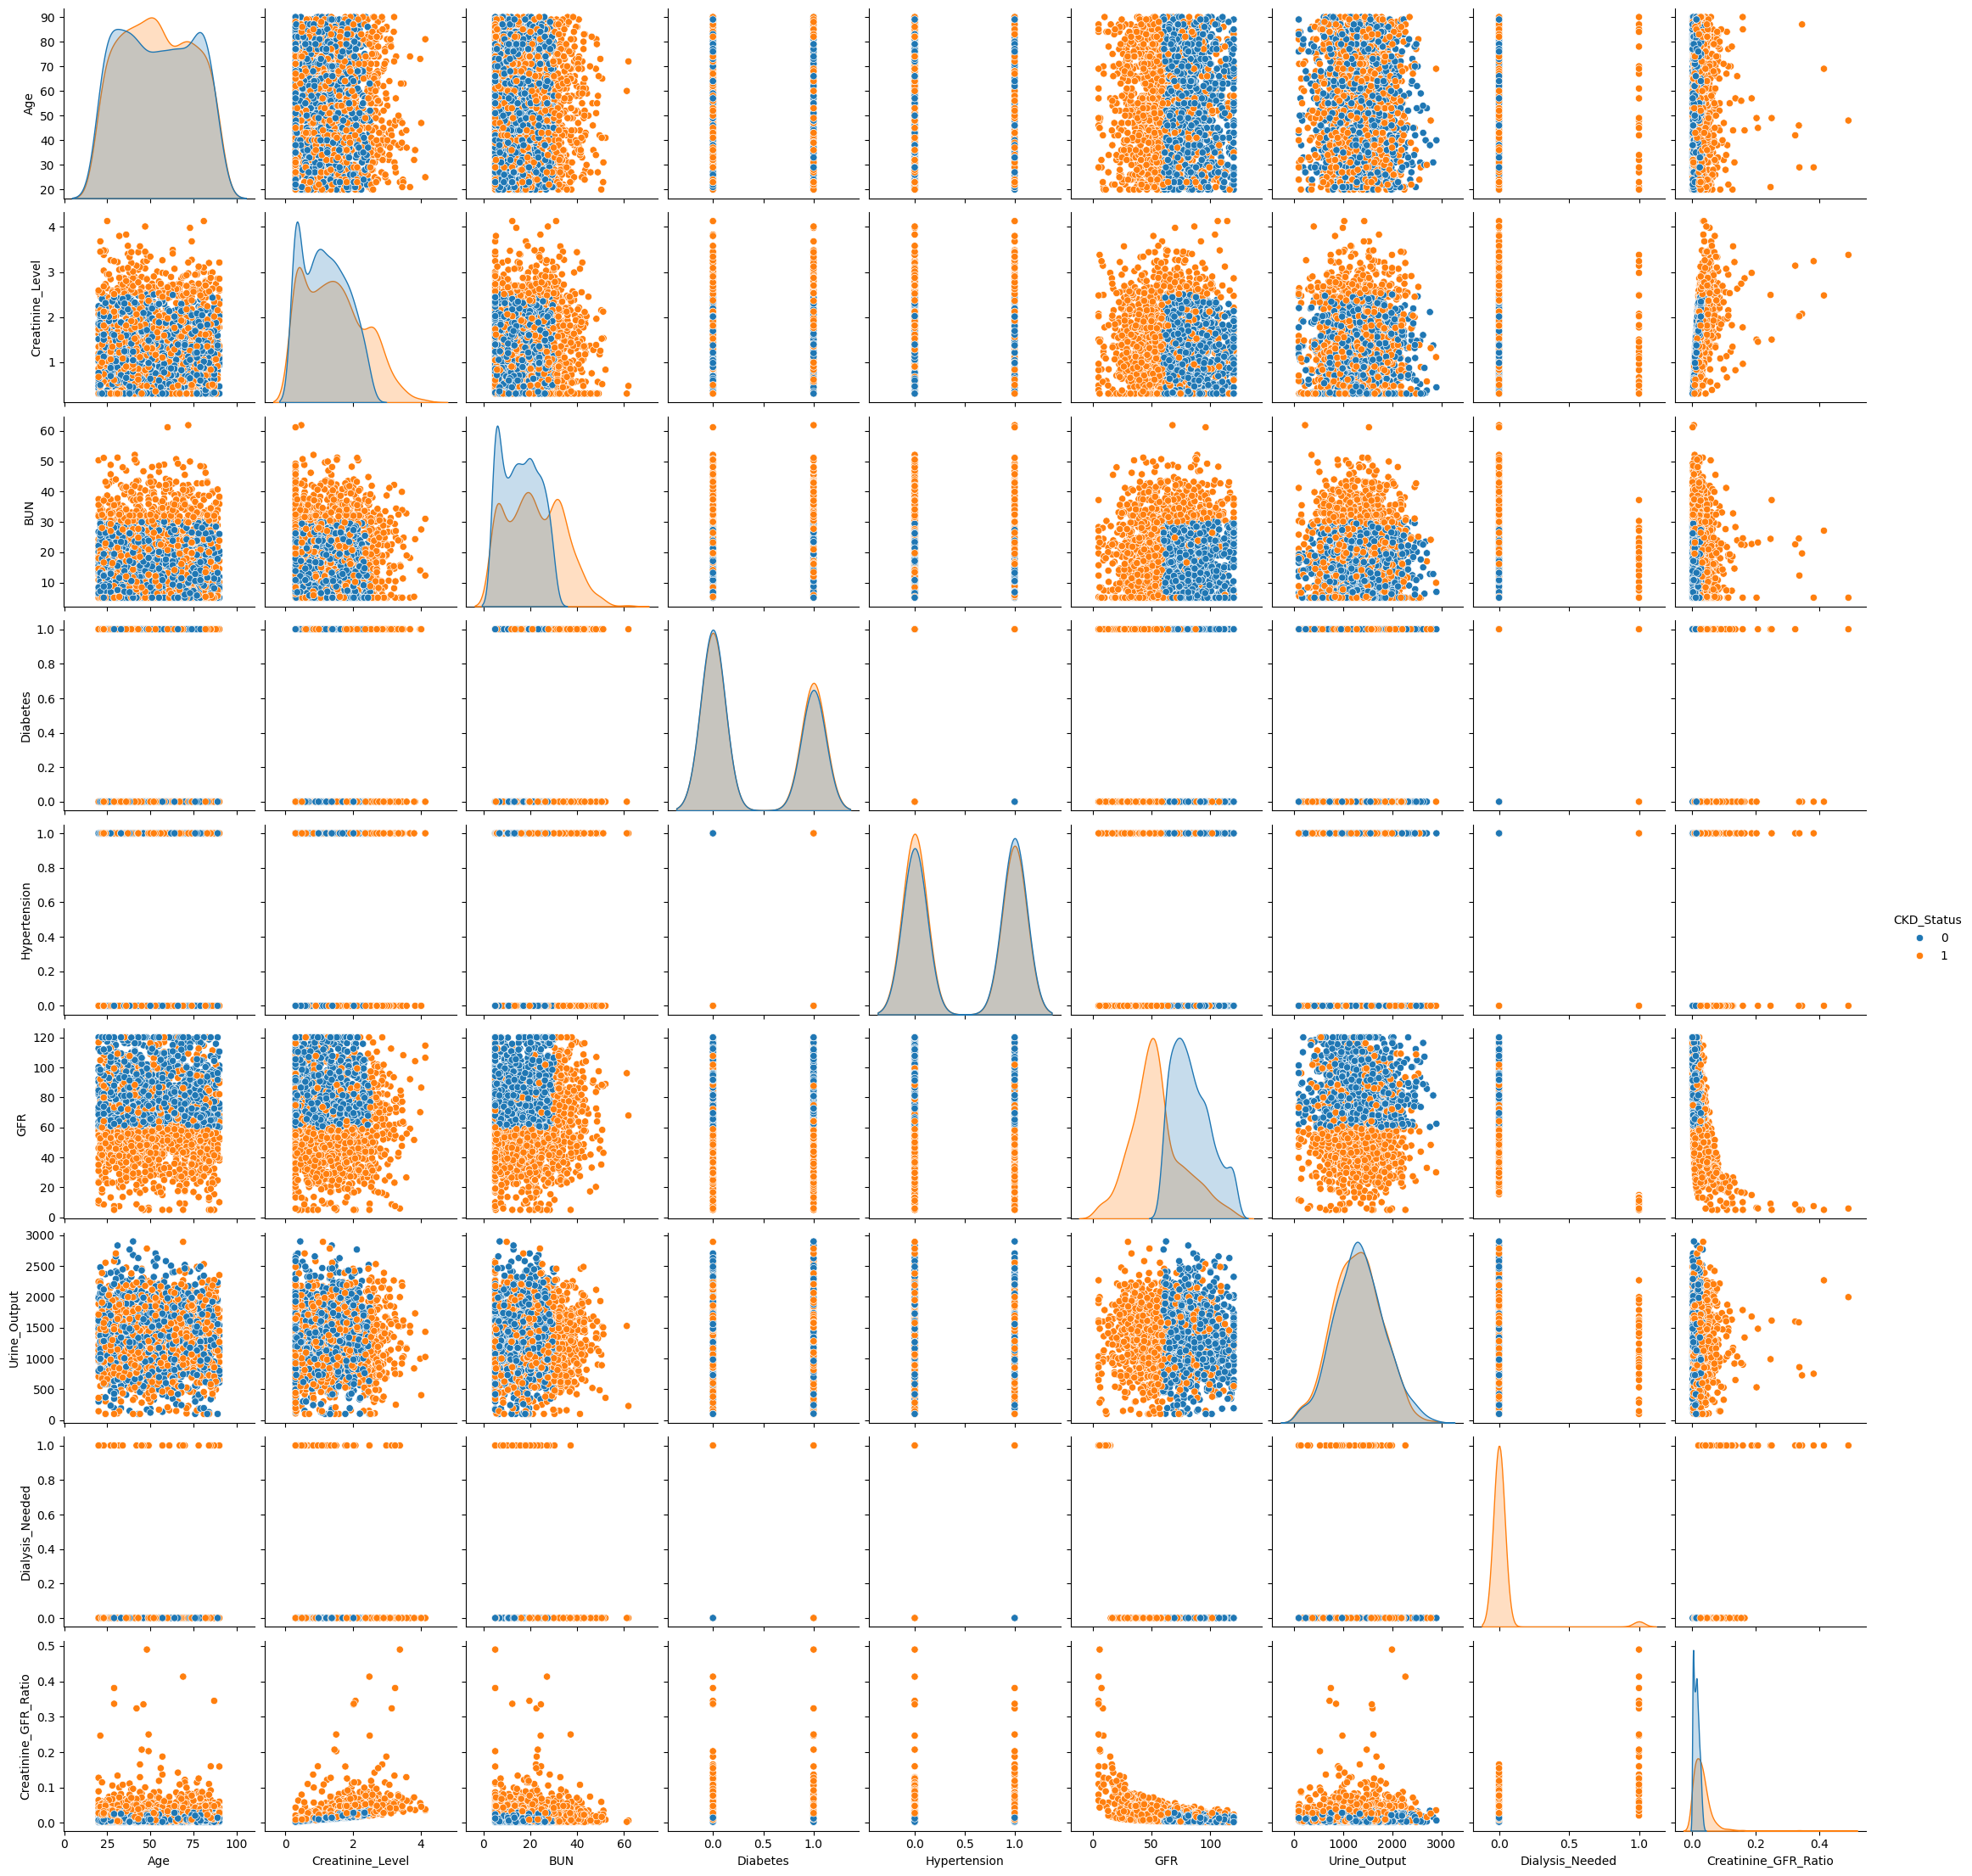

In [15]:
# Visualization
sns.pairplot(data, hue = 'CKD_Status')

relation between all features and each other with the status

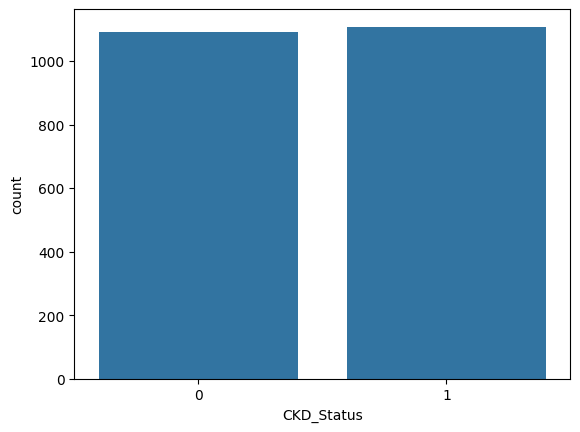

In [16]:
sns.countplot(x=data['CKD_Status'])
plt.show()

the number of each stats 1= kidney problem 0=kideny healthy

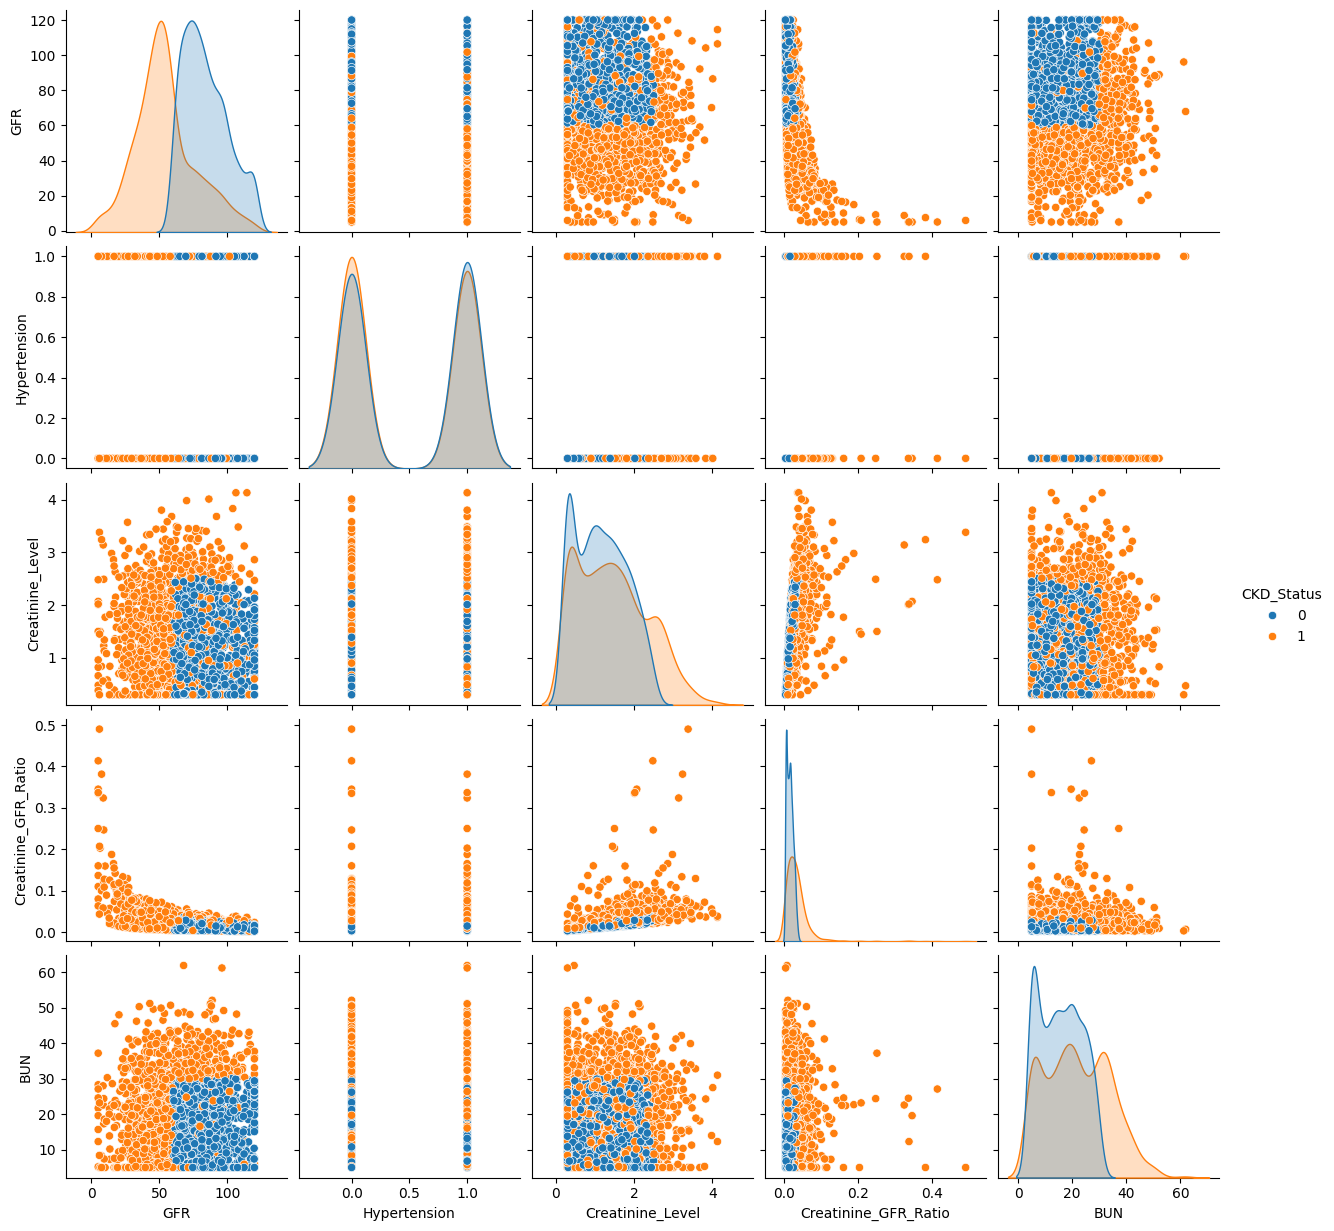

In [17]:
sns.pairplot(data, hue = 'CKD_Status',
             vars = ['GFR', 'Hypertension', 'Creatinine_Level', 'Creatinine_GFR_Ratio', 'BUN'] )


relation between the most important feature that affect kidney

<Axes: xlabel='GFR', ylabel='count'>

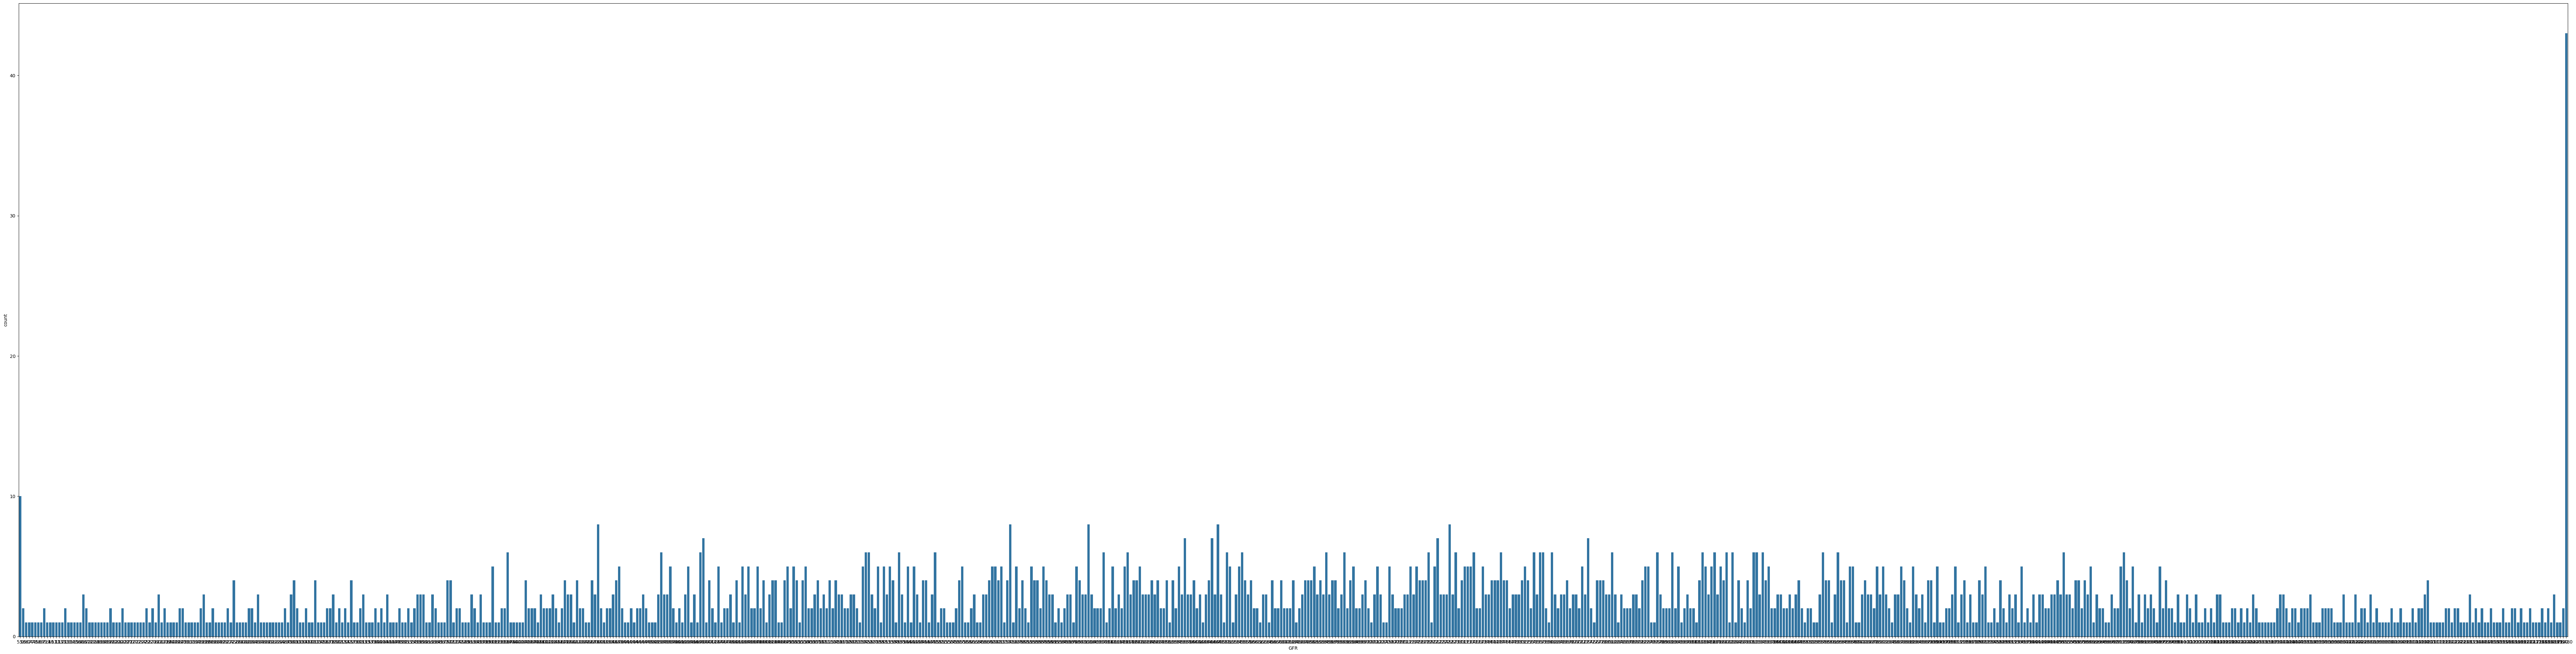

In [18]:
plt.figure(figsize = (100,25))
sns.countplot(x=data['GFR'])

number of GFR for each one (the most important feature)

<Axes: >

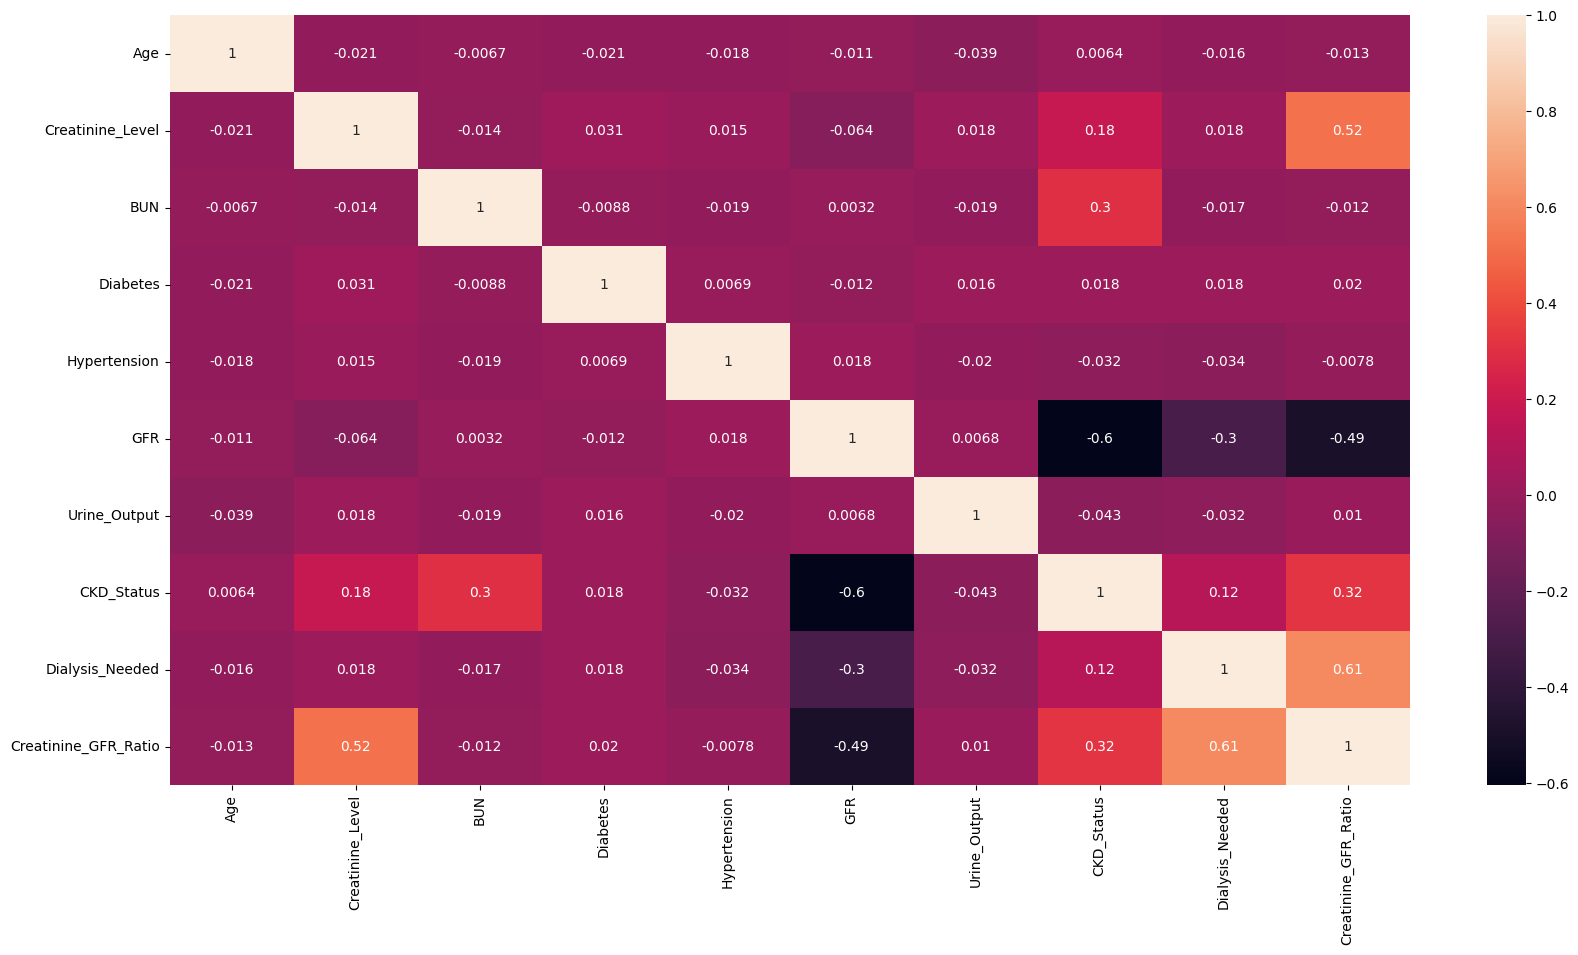

In [19]:
plt.figure(figsize=(20,10))
#Increase size of Heatmap (was very small in first trial)

sns.heatmap(data.corr(), annot=True)
#This shows correlation between features

heat map to the relation of all variable as color gets lighter the relation is stronger

<Axes: >

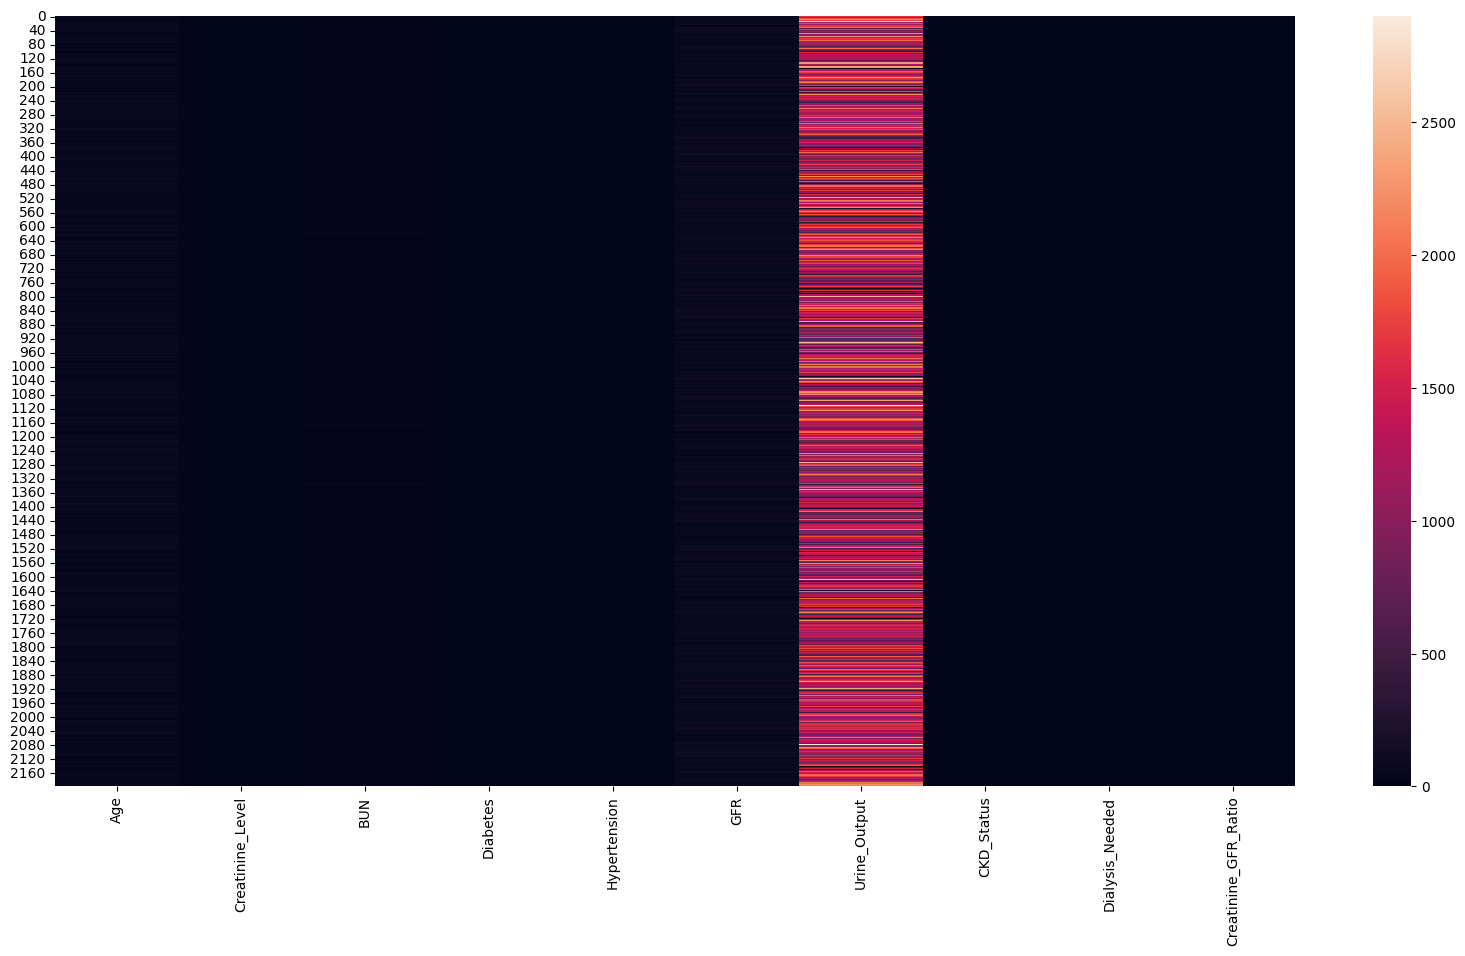

In [20]:
plt.figure(figsize=(20,10))
sns.heatmap(data)

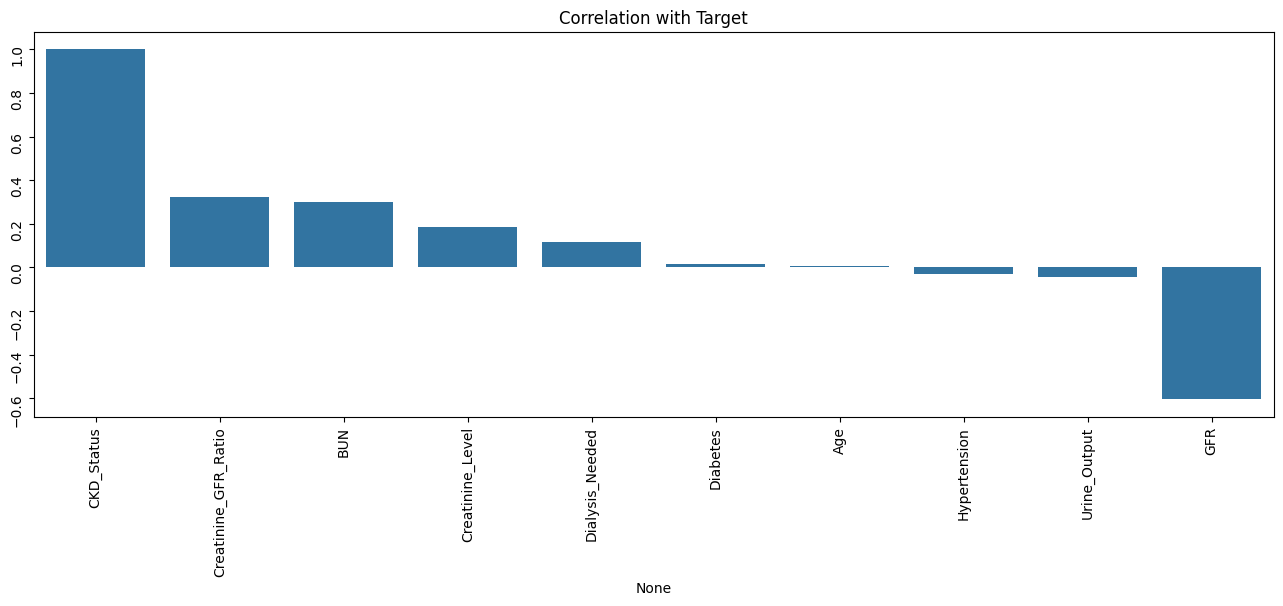

In [21]:
plt.figure(figsize=(16,5))

corr = data.corr(numeric_only=True)['CKD_Status'].sort_values(ascending=False)

ax = sns.barplot(
    x=corr.index,
    y=corr.values
)

ax.tick_params(labelrotation=90)

plt.title("Correlation with Target")

plt.show()

relation between each feature and the CKD_status is it inverse or direct and by how far

**step 5 Spliting and modeling:**

In [22]:
# ==========================================
# Import Libraries
# ==========================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier


# ==========================================
# Preparing the Data
# ==========================================

X = data.drop("CKD_Status", axis=1)
# Takes the whole dataset and removes the "CKD_Status" column
# because we do not want the model to see the answer while learning

Y = data["CKD_Status"]
# X contains the patient information (features)
# Y contains the target values:
# 0 → Healthy
# 1 → Chronic Kidney Disease


# ==========================================
# Splitting the Dataset
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(  X, Y, test_size=0.3)

# Splits the dataset into:
# 70% training data
# 30% testing data


# ==========================================
# Feature Scaling
# ==========================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Standardization makes all features have similar scales
# This helps machine learning models perform better


# ==========================================
# Model 1: Logistic Regression
# ==========================================

model1 = LogisticRegression()

# Logistic Regression is a classification algorithm
# It predicts whether the patient:
# 0 → Healthy
# 1 → Has Chronic Kidney Disease

model1.fit(X_train, y_train)

# The model learns relationships between:
# X_train → input features
# y_train → correct answers


# ==========================================
# Predicting Using Logistic Regression
# ==========================================

y_pred1 = model1.predict(X_test)

# The model predicts results using unseen test data


# ==========================================
# Evaluating Logistic Regression
# ==========================================

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred1))

# accuracy_score compares:
# Real values → y_test
# Predicted values → y_pred1


# ==========================================
# Model 2: Artificial Neural Network (ANN)
# ==========================================

# Sequential → layers are stacked one after another
# Dense → fully connected neural network layer
# Input → defines the number of input features

model2 = Sequential([

    Input(shape=(X_train.shape[1],)),

    Dense(16, activation='relu'),

    Dense(8, activation='relu'),

    Dense(1, activation='sigmoid')

])

# ANN Structure:
# Input Layer → Hidden Layer (16 neurons)
# → Hidden Layer (8 neurons)
# → Output Layer (1 neuron)

# relu activation:
# Helps the network learn complex patterns

# sigmoid activation:
# Produces output values between 0 and 1


# ==========================================
# Compiling the ANN Model
# ==========================================

model2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# optimizer='adam'
# Updates the model weights to improve learning

# loss='binary_crossentropy'
# Measures prediction error for binary classification

# metrics=['accuracy']
# Displays model accuracy during training


# ==========================================
# Training the ANN Model
# ==========================================

model2.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=16
)

# epochs=10
# The model sees the entire dataset 10 times

# batch_size=16
# The data is processed in groups of 16 rows

# Training process:
# 1- Make predictions
# 2- Compare predictions with actual answers
# 3- Calculate error (loss)
# 4- Adjust weights
# 5- Improve performance


# ==========================================
# Evaluating the ANN Model
# ==========================================

loss, acc = model2.evaluate(X_test, y_test)

print("ANN Loss:", loss)
print("ANN Accuracy:", acc)

# model.evaluate() returns:
# 1- loss → how wrong the predictions are
# 2- accuracy → how correct the predictions are


# ==========================================
# Model 3: Support Vector Classifier (SVC)
# ==========================================

svc_classifier = SVC()

svc_classifier.fit(X_train, y_train)

y_pred_svc = svc_classifier.predict(X_test)

print("SVC Accuracy:",
      accuracy_score(y_test, y_pred_svc))

# SVC tries to find the best boundary
# that separates the classes


# ==========================================
# Model 4: K-Nearest Neighbors (KNN)
# ==========================================

knn_classifier = KNeighborsClassifier(
    n_neighbors=5,
    metric='minkowski',
    p=2
)

# n_neighbors=5
# The model checks the 5 nearest neighbors

# metric='minkowski' with p=2
# Uses Euclidean distance

knn_classifier.fit(X_train, y_train)

y_pred_knn = knn_classifier.predict(X_test)

print("KNN Accuracy:",
      accuracy_score(y_test, y_pred_knn))


# ==========================================
# Model 5: Decision Tree Classifier
# ==========================================

dt_classifier = DecisionTreeClassifier(
    criterion='entropy',
    random_state=51
)

# criterion='entropy'
# Uses information gain to split the data

# random_state=51
# Ensures reproducible results

dt_classifier.fit(X_train, y_train)

y_pred_dt = dt_classifier.predict(X_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test, y_pred_dt))

Logistic Regression Accuracy: 0.8196969696969697


Epoch 1/10


97/97 [==============================] - 0s 599us/step - loss: 0.5293 - accuracy: 0.7477
Epoch 2/10
97/97 [==============================] - 0s 466us/step - loss: 0.4074 - accuracy: 0.8264
Epoch 3/10
97/97 [==============================] - 0s 450us/step - loss: 0.3458 - accuracy: 0.8557
Epoch 4/10
97/97 [==============================] - 0s 428us/step - loss: 0.3111 - accuracy: 0.8661
Epoch 5/10
97/97 [==============================] - 0s 451us/step - loss: 0.2865 - accuracy: 0.8791
Epoch 6/10
97/97 [==============================] - 0s 423us/step - loss: 0.2672 - accuracy: 0.8908
Epoch 7/10
97/97 [==============================] - 0s 447us/step - loss: 0.2486 - accuracy: 0.8973
Epoch 8/10
97/97 [==============================] - 0s 444us/step - loss: 0.2299 - accuracy: 0.9109
Epoch 9/10
97/97 [==============================] - 0s 444us/step - loss: 0.2108 - accuracy: 0.9194
Epoch 10/10
21/21 [============================

represent the model of logistic regression, Ann, SVC, knn, Dicision tree 

**step 6 comparisson between the models:**

In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

results = []

# =========================
# Logistic Regression
# =========================

y_pred_lr = model1.predict(X_test)

results.append([
    "Logistic Regression",
    accuracy_score(y_test, y_pred_lr),
    precision_score(y_test, y_pred_lr),
    recall_score(y_test, y_pred_lr),
    f1_score(y_test, y_pred_lr),
    roc_auc_score(y_test, y_pred_lr)
])

# =========================
# ANN
# =========================

y_pred_ann = model2.predict(X_test)
y_pred_ann = (y_pred_ann > 0.5).astype(int)

results.append([
    "ANN",
    accuracy_score(y_test, y_pred_ann),
    precision_score(y_test, y_pred_ann),
    recall_score(y_test, y_pred_ann),
    f1_score(y_test, y_pred_ann),
    roc_auc_score(y_test, y_pred_ann)
])

# =========================
# SVC
# =========================

y_pred_svc = svc_classifier.predict(X_test)

results.append([
    "SVC",
    accuracy_score(y_test, y_pred_svc),
    precision_score(y_test, y_pred_svc),
    recall_score(y_test, y_pred_svc),
    f1_score(y_test, y_pred_svc),
    roc_auc_score(y_test, y_pred_svc)
])

# =========================
# KNN
# =========================

y_pred_knn = knn_classifier.predict(X_test)

results.append([
    "KNN",
    accuracy_score(y_test, y_pred_knn),
    precision_score(y_test, y_pred_knn),
    recall_score(y_test, y_pred_knn),
    f1_score(y_test, y_pred_knn),
    roc_auc_score(y_test, y_pred_knn)
])

# =========================
# Decision Tree
# =========================

y_pred_dt = dt_classifier.predict(X_test)

results.append([
    "Decision Tree",
    accuracy_score(y_test, y_pred_dt),
    precision_score(y_test, y_pred_dt),
    recall_score(y_test, y_pred_dt),
    f1_score(y_test, y_pred_dt),
    roc_auc_score(y_test, y_pred_dt)
])

# =========================
# Comparison Table
# =========================

comparison = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
)

print(comparison)

21/21 [==============================] - 0s 418us/step
                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression  0.819697   0.803419  0.849398  0.825769  0.819516
1                  ANN  0.898485   0.871148  0.936747  0.902758  0.898252
2                  SVC  0.939394   0.919540  0.963855  0.941176  0.939245
3                  KNN  0.871212   0.894569  0.843373  0.868217  0.871382
4        Decision Tree  1.000000   1.000000  1.000000  1.000000  1.000000


**step 7 Evaluation for each model:**

In [24]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# =========================
# Logistic Regression
# =========================

y_pred_lr = model1.predict(X_test)

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_lr))

# =========================
# SVC
# =========================

y_pred_svc = svc_classifier.predict(X_test)

print("\nSVC")
print("Accuracy:", accuracy_score(y_test, y_pred_svc))
print("Precision:", precision_score(y_test, y_pred_svc))
print("Recall:", recall_score(y_test, y_pred_svc))
print("F1 Score:", f1_score(y_test, y_pred_svc))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_svc))

# =========================
# KNN
# =========================

y_pred_knn = knn_classifier.predict(X_test)

print("\nKNN")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))
print("F1 Score:", f1_score(y_test, y_pred_knn))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_knn))

# =========================
# Decision Tree
# =========================

y_pred_dt = dt_classifier.predict(X_test)

print("\nDecision Tree")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_dt))

# =========================
# ANN
# =========================

y_pred_ann = model2.predict(X_test)

y_pred_ann = (y_pred_ann > 0.5).astype(int)

print("\nANN")
print("Accuracy:", accuracy_score(y_test, y_pred_ann))
print("Precision:", precision_score(y_test, y_pred_ann))
print("Recall:", recall_score(y_test, y_pred_ann))
print("F1 Score:", f1_score(y_test, y_pred_ann))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_ann))

Logistic Regression
Accuracy: 0.8196969696969697
Precision: 0.8034188034188035
Recall: 0.8493975903614458
F1 Score: 0.8257686676427526
ROC-AUC: 0.8195158683514545

SVC
Accuracy: 0.9393939393939394
Precision: 0.9195402298850575
Recall: 0.963855421686747
F1 Score: 0.9411764705882353
ROC-AUC: 0.9392447840141053

KNN
Accuracy: 0.8712121212121212
Precision: 0.8945686900958466
Recall: 0.8433734939759037
F1 Score: 0.8682170542635659
ROC-AUC: 0.8713818689391715

Decision Tree
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
ROC-AUC: 1.0
21/21 [==============================] - 0s 404us/step

ANN
Accuracy: 0.8984848484848484
Precision: 0.8711484593837535
Recall: 0.9367469879518072
F1 Score: 0.9027576197387518
ROC-AUC: 0.8982515427563914


In [ ]:

# =========================
# Input Patient Data
# =========================

patient = pd.DataFrame({
    "Age": [89],
    "Creatinine_Level": [1.48],
    "BUN": [5.2],
    "Diabetes": [0],
    "Hypertension": [0],
    "GFR": [74.5],
    "Urine_Output": [988],
    "Dialysis_Needed": [0],
    "Creatinine_GFR_Ratio": [1.48 / (74.5 + 1)]
})

patient = patient[X.columns]

# Scale input using same scaler
patient_scaled = scaler.transform(patient)

# =========================
# Predictions
# =========================

models_predictions = {}

# Logistic Regression
models_predictions["Logistic Regression"] = model1.predict(patient_scaled)[0]

# SVC
models_predictions["SVC"] = svc_classifier.predict(patient_scaled)[0]

# KNN
models_predictions["KNN"] = knn_classifier.predict(patient_scaled)[0]

# Decision Tree
models_predictions["Decision Tree"] = dt_classifier.predict(patient_scaled)[0]

# ANN
ann_prob = model2.predict(patient_scaled)[0][0]
ann_pred = 1 if ann_prob > 0.5 else 0
models_predictions["ANN"] = ann_pred

# =========================
# Show Results
# =========================

for model_name, pred in models_predictions.items():
    if pred == 1:
        result = "Kidney Problem"
    else:
        result = "Kidney Healthy"
    
    print(model_name, "Prediction:", result)

print("ANN Probability:", ann_prob) 

1/1 [==============================] - 0s 12ms/step
Logistic Regression Prediction: Kidney Healthy
SVC Prediction: Kidney Healthy
KNN Prediction: Kidney Healthy
Decision Tree Prediction: Kidney Healthy
ANN Prediction: Kidney Healthy
ANN Probability: 0.03472506


Ann probability the percent of how much the ANN system trust that the person has kidney problem